In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import numpy as np

# COMPARANDO CATEGORIAS

Os gráficos deste capítulo visam ajudar nossos leitores a comparar valores entre categorias. Barras, linhas e pontos permitem que os leitores façam comparações tanto dentro de grupos quanto entre eles. Em alguns casos, queremos que o leitor visualize tanto os níveis quanto as variações, ou alguma outra combinação de variáveis; em outros, queremos concentrar sua atenção em uma comparação específica.

O desafio ao comparar dados categóricos é decidir o que queremos que o gráfico transmita. Existe um argumento ou uma narrativa principal? Há algum aspecto que possa ser identificado como a comparação mais importante que se deseja que o leitor faça? Como criadores de gráficos, precisamos priorizar a função que queremos que eles desempenhem. Ao incluir todas as barras ou pontos no gráfico, podemos acabar obscurecendo a mensagem que desejamos transmitir.

Este capítulo começa com o gráfico de barras. Assim como o gráfico de linhas que dará início ao próximo capítulo, o gráfico de barras é familiar à maioria dos leitores, o que o torna uma escolha conveniente para orientá-los ao comparar categorias ou observar mudanças ao longo do tempo. Ele também ocupa o topo do diagrama de hierarquia de percepção visual. Não é obrigatório fornecer sempre os valores exatos aos leitores, mas, quando o fazemos, o gráfico de barras é uma excelente escolha.



## BARRAS DIVERGENTES

Uma variação do gráfico de barras empilhadas é aquela em que as pilhas divergem de uma linha de base central em direções opostas. Esse tipo de gráfico é frequentemente encontrado em pesquisas nas quais as respostas estão organizadas em faixas que variam, por exemplo, de "discordo totalmente" a "concordo totalmente". Tais gráficos são frequentemente chamados de "escalas Likert", nome dado em homenagem ao psicólogo Rensis Likert, que as criou no início da década de 1930.

Neste exemplo, com base em dados do *International Social Survey Programme*, perguntou-se aos participantes da pesquisa se eles acreditam que é responsabilidade do governo reduzir a desigualdade de renda. Ao agrupar as respostas de "discordância" e "concordância" em lados opostos de uma linha de referência central, podemos comparar o sentimento geral entre os diferentes países.

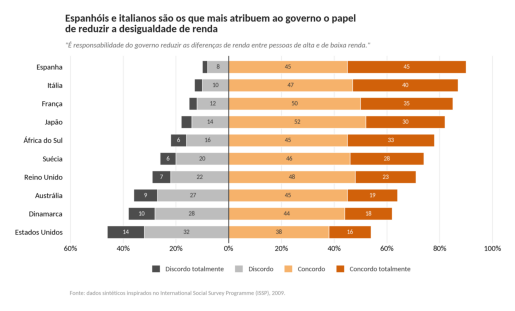

In [2]:
img = mpimg.imread('figures/fig5_likert_issp.png')
plt.imshow(img)
plt.axis('off')
plt.show()

Uma vantagem deste gráfico é que os sentimentos são apresentados de forma clara: as respostas de discordância projetam-se para a esquerda (numa direção que normalmente associamos a algo negativo) e as de concordância, para a direita. Essa abordagem funciona bem se o seu público estiver mais interessado no sentimento geral de cada lado, e não necessariamente em comparações entre os componentes individuais. Se o foco principal forem as comparações individuais, um gráfico de barras pareadas pode atender igualmente bem à necessidade.

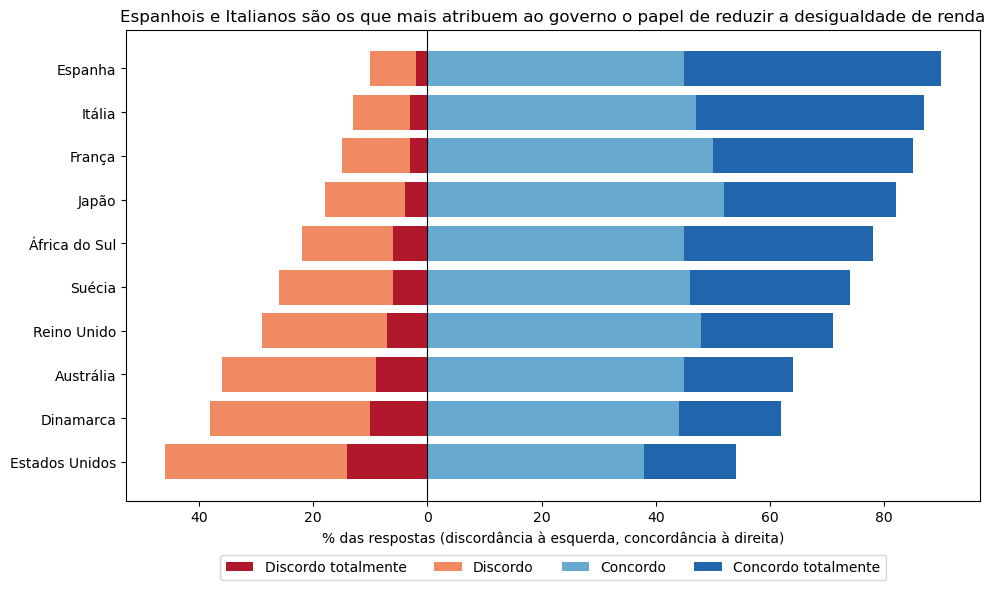

In [3]:
# Carregar os dados da pesquisa (linhas de comentário no início do arquivo)
likert = pd.read_csv('../Data/likert_issp.csv', comment='#')

# Ordenar os países pela força da concordância (Concordo + Concordo totalmente)
likert['Concordancia_total'] = likert['Concordo'] + likert['Concordo totalmente']
likert = likert.sort_values(by='Concordancia_total', ascending=True).reset_index(drop=True)

posicoes = np.arange(len(likert))

# Lado esquerdo (discordância): valores negativos, à esquerda da linha de base em zero
discordo_totalmente = -likert['Discordo totalmente']
discordo = -likert['Discordo']

# Lado direito (concordância): valores positivos, à direita da linha de base em zero
concordo = likert['Concordo']
concordo_totalmente = likert['Concordo totalmente']

fig, ax = plt.subplots(figsize=(10, 6))

# Empilhar cada lado a partir do zero, afastando-se do centro
ax.barh(posicoes, discordo_totalmente, color='#b2182b', zorder=3, label='Discordo totalmente')
ax.barh(posicoes, discordo, left=discordo_totalmente, color='#ef8a62', zorder=3, label='Discordo')
ax.barh(posicoes, concordo, color='#67a9cf', zorder=3, label='Concordo')
ax.barh(posicoes, concordo_totalmente, left=concordo, color='#2166ac', zorder=3, label='Concordo totalmente')

# Linha de base central
ax.axvline(x=0, color='black', linewidth=0.8, zorder=4)

ax.set_yticks(posicoes)
ax.set_yticklabels(likert['pais'])

ax.set_title('Espanhois e Italianos são os que mais atribuem ao governo o papel '
             'de reduzir a desigualdade de renda')
ax.set_xlabel('% das respostas (discordância à esquerda, concordância à direita)')

# Formatar o eixo x para mostrar valores absolutos (sem o sinal negativo)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(abs(x))}'))

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

fig.tight_layout()
plt.show()

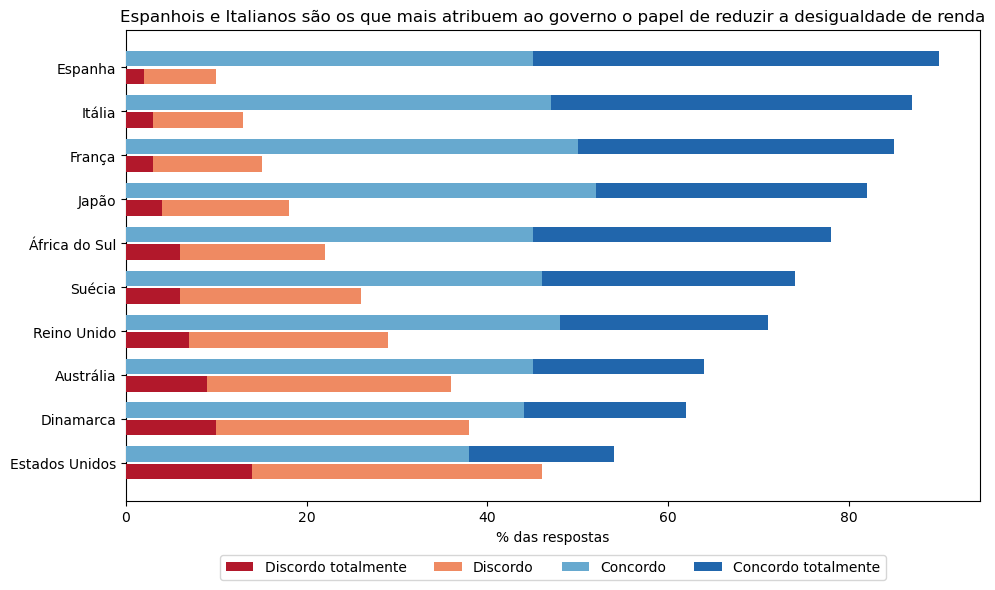

In [4]:
# Versão em barras pareadas: para cada país, uma barra empilhada com as respostas
# negativas (Discordo totalmente + Discordo) e outra com as positivas
# (Concordo + Concordo totalmente), lado a lado.
posicoes = np.arange(len(likert))
deslocamento = 0.2
altura_barra = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Barra das respostas negativas (discordância)
ax.barh(posicoes - deslocamento, likert['Discordo totalmente'], height=altura_barra,
        color='#b2182b', zorder=3, label='Discordo totalmente')
ax.barh(posicoes - deslocamento, likert['Discordo'], left=likert['Discordo totalmente'],
        height=altura_barra, color='#ef8a62', zorder=3, label='Discordo')

# Barra das respostas positivas (concordância)
ax.barh(posicoes + deslocamento, likert['Concordo'], height=altura_barra,
        color='#67a9cf', zorder=3, label='Concordo')
ax.barh(posicoes + deslocamento, likert['Concordo totalmente'], left=likert['Concordo'],
        height=altura_barra, color='#2166ac', zorder=3, label='Concordo totalmente')

ax.set_yticks(posicoes)
ax.set_yticklabels(likert['pais'])

ax.set_title('Espanhois e Italianos são os que mais atribuem ao governo o papel '
             'de reduzir a desigualdade de renda')
ax.set_xlabel('% das respostas')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

fig.tight_layout()
plt.show()

Por que percebemos esses valores associados ao lado esquerdo como negativos? Ao longo da história ocidental, o conceito de "esquerda" — e até mesmo as pessoas canhotas — tem sido marcado por conotações negativas. Considere a etimologia da palavra: *left* (esquerda, em inglês) deriva da palavra do inglês antigo *lyft*, que significa "fraco". Em latim, a palavra *sinister* refere-se ao lado esquerdo ou à direção da mão esquerda. A palavra *right* (direita/correto, em inglês) vem do inglês antigo *riht*, cujo significado original era "reto" — ou seja, não curvado nem torto. É por isso que existem expressões como "ficar ereto" (*standing upright*), "fazer a coisa certa" (*do the right thing*) ou "a resposta certa" (*the right answer*), todas as quais remetem a bondade e correção. Isso também pode ser observado em outros idiomas: em espanhol, por exemplo, a palavra *derecha* significa "direita", e o termo *derecho*, que deriva da mesma raiz, significa "reto".

Assim como ocorre com o gráfico de barras empilhadas, o desafio ao visualizar esse tipo de dado é que precisamos fazer comparações tanto dentro das categorias quanto entre elas. Dispor as barras em direções opostas dificulta a comparação dos totais dos dois grupos. Em outras palavras, torna-se difícil comparar a proporção total de pessoas que discordam com a proporção total de pessoas que concordam. Essa tarefa é um pouco mais simples no gráfico de barras pareadas, mas, por outro lado, perde-se a conotação de positivo versus negativo presente no gráfico divergente. Dependendo dos padrões dos dados e da quantidade de categorias e grupos, o gráfico pode acabar parecendo visualmente poluído ou sobrecarregado.

É preciso ter cuidado redobrado ao utilizar um gráfico de barras divergentes quando houver uma categoria "neutra". Por definição, a resposta neutra em uma pesquisa não indica concordância nem discordância e, portanto, não deve ser agrupada com nenhuma das duas categorias.

Posicionar a categoria neutra no meio do gráfico, ao longo da linha de base vertical, gera um desalinhamento entre os dois grupos e sugere que as respostas neutras estão divididas entre os dois sentimentos. Isso também significa que nenhum dos segmentos fica alinhado a uma linha de base vertical. Colocá-la na lateral do gráfico é uma estratégia melhor, pois as categorias "discordo", "concordo" e "neutro" passam a ficar alinhadas aos seus próprios eixos verticais, embora a categoria neutra receba certo destaque por estar posicionada na lateral.

Outra alternativa — independentemente de haver ou não uma categoria neutra — é o gráfico de barras empilhadas, conforme mostrado na página seguinte. Nessa visualização, as diferentes categorias somam 100%, permitindo comparar mais facilmente os totais entre os países. Uma boa estratégia é marcar valores agregados específicos para orientar o leitor. Aqui, por exemplo, marquei a posição de 50% para deixar claro em quais países os totais de opiniões de "concordância" e "discordância" representam, no mínimo, metade do total.

Você pode ir além e decompor o gráfico em seus componentes, como discutimos na seção anterior. De modo geral, assim como ocorre com muitos gráficos, a variação escolhida dependerá dos seus objetivos.

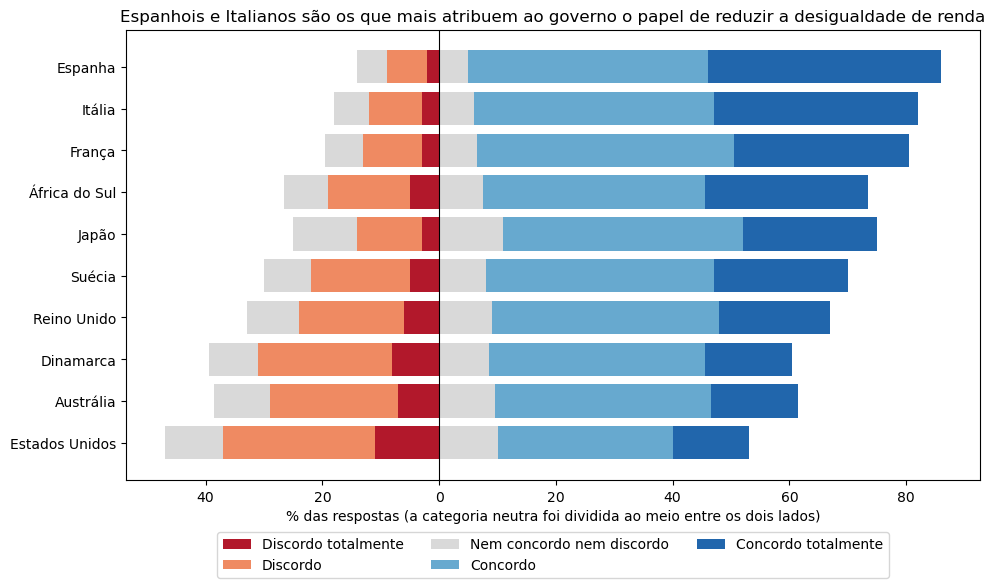

In [5]:
# Carregar os dados com a categoria neutra separada (5 faixas)
likert5 = pd.read_csv('../Data/likert_issp_5cat.csv', comment='#')
likert5['Concordancia_total'] = likert5['Concordo'] + likert5['Concordo totalmente']
likert5 = likert5.sort_values(by='Concordancia_total', ascending=True).reset_index(drop=True)

posicoes = np.arange(len(likert5))

# --------------------------------------------------------------------------- #
# Gráfico 1 — Escala de Likert dividindo a neutra ao meio entre os dois lados
# --------------------------------------------------------------------------- #
metade_neutra = likert5['Nem concordo nem discordo'] / 2

discordo_totalmente = -likert5['Discordo totalmente']
discordo = -likert5['Discordo']
neutra_esquerda = -metade_neutra

neutra_direita = metade_neutra
concordo = likert5['Concordo']
concordo_totalmente = likert5['Concordo totalmente']

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(posicoes, discordo_totalmente, color='#b2182b', zorder=3, label='Discordo totalmente')
ax.barh(posicoes, discordo, left=discordo_totalmente, color='#ef8a62', zorder=3, label='Discordo')
ax.barh(posicoes, neutra_esquerda, left=discordo_totalmente + discordo,
        color='#d9d9d9', zorder=3, label='Nem concordo nem discordo')
ax.barh(posicoes, neutra_direita, color='#d9d9d9', zorder=3)
ax.barh(posicoes, concordo, left=neutra_direita, color='#67a9cf', zorder=3, label='Concordo')
ax.barh(posicoes, concordo_totalmente, left=neutra_direita + concordo,
        color='#2166ac', zorder=3, label='Concordo totalmente')

ax.axvline(x=0, color='black', linewidth=0.8, zorder=4)

ax.set_yticks(posicoes)
ax.set_yticklabels(likert5['pais'])

ax.set_title('Espanhois e Italianos são os que mais atribuem ao governo o papel '
             'de reduzir a desigualdade de renda')
ax.set_xlabel('% das respostas (a categoria neutra foi dividida ao meio entre os dois lados)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(abs(x))}'))

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

fig.tight_layout()
plt.show()

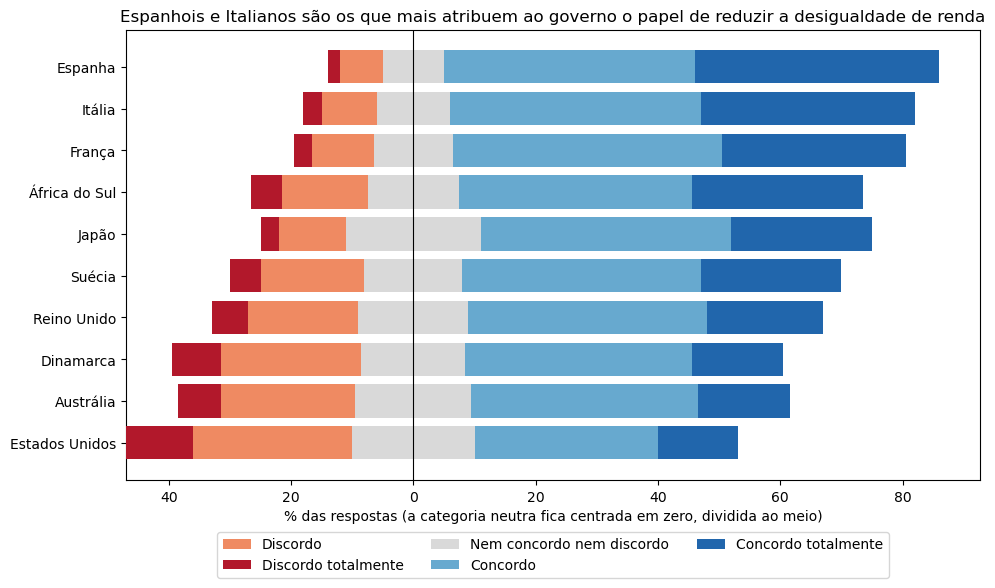

In [6]:
# --------------------------------------------------------------------------- #
# Gráfico 1b — Escala de Likert com a neutra centrada em zero, dividida ao meio
# (metade à esquerda, metade à direita), e as demais categorias empilhadas
# para fora a partir das bordas da neutra
# --------------------------------------------------------------------------- #
metade_neutra = likert5['Nem concordo nem discordo'] / 2

fig, ax = plt.subplots(figsize=(10, 6))

# Lado esquerdo: da borda da neutra para fora (Discordo, depois Discordo totalmente)
acumulado_esquerda = metade_neutra.copy()
for categoria, cor in [('Discordo', '#ef8a62'), ('Discordo totalmente', '#b2182b')]:
    valor = likert5[categoria]
    ax.barh(posicoes, valor, left=-(acumulado_esquerda + valor), color=cor, zorder=3, label=categoria)
    acumulado_esquerda += valor

# Categoria neutra, centrada em zero (metade à esquerda, metade à direita)
ax.barh(posicoes, metade_neutra, left=-metade_neutra, color='#d9d9d9', zorder=3,
        label='Nem concordo nem discordo')
ax.barh(posicoes, metade_neutra, left=0, color='#d9d9d9', zorder=3)

# Lado direito: da borda da neutra para fora (Concordo, depois Concordo totalmente)
acumulado_direita = metade_neutra.copy()
for categoria, cor in [('Concordo', '#67a9cf'), ('Concordo totalmente', '#2166ac')]:
    valor = likert5[categoria]
    ax.barh(posicoes, valor, left=acumulado_direita, color=cor, zorder=3, label=categoria)
    acumulado_direita += valor

ax.axvline(x=0, color='black', linewidth=0.8, zorder=4)

ax.set_yticks(posicoes)
ax.set_yticklabels(likert5['pais'])

ax.set_title('Espanhois e Italianos são os que mais atribuem ao governo o papel '
             'de reduzir a desigualdade de renda')
ax.set_xlabel('% das respostas (a categoria neutra fica centrada em zero, dividida ao meio)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(abs(x))}'))

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

fig.tight_layout()
plt.show()

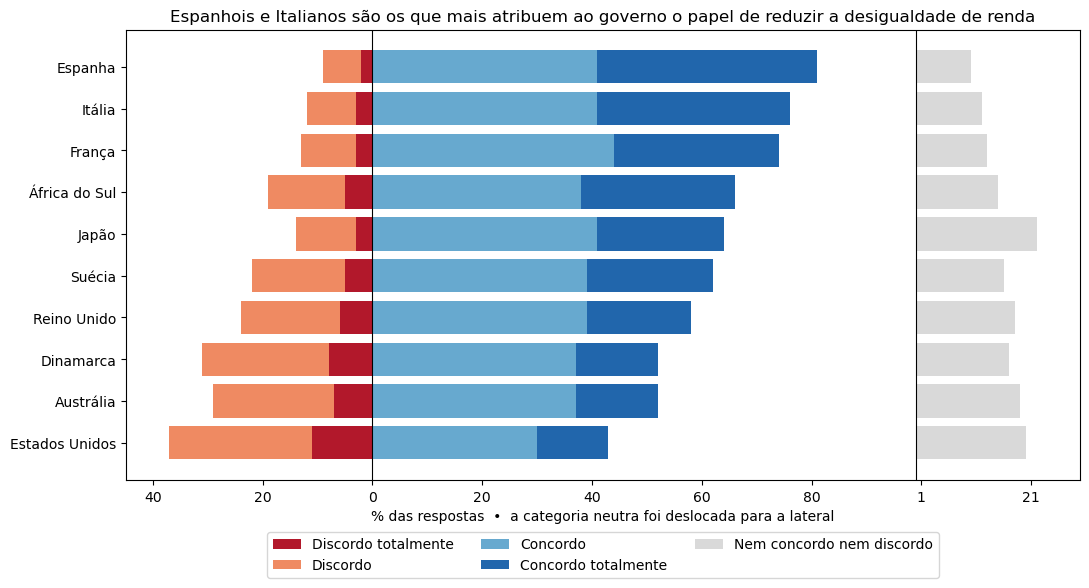

In [7]:
# --------------------------------------------------------------------------- #
# Gráfico 2 — Escala de Likert descartando a neutra do eixo central e
# posicionando-a à parte, alinhada à sua própria linha de base
# --------------------------------------------------------------------------- #
discordo_totalmente = -likert5['Discordo totalmente']
discordo = -likert5['Discordo']
concordo = likert5['Concordo']
concordo_totalmente = likert5['Concordo totalmente']

GAP = 15  # espaço em branco entre o gráfico divergente e a categoria neutra
base_neutra = concordo_totalmente.max() + concordo.max() + GAP  # linha de base própria

fig, ax = plt.subplots(figsize=(11, 6))

# Lado divergente: discordância à esquerda, concordância à direita
ax.barh(posicoes, discordo_totalmente, color='#b2182b', zorder=3, label='Discordo totalmente')
ax.barh(posicoes, discordo, left=discordo_totalmente, color='#ef8a62', zorder=3, label='Discordo')
ax.barh(posicoes, concordo, color='#67a9cf', zorder=3, label='Concordo')
ax.barh(posicoes, concordo_totalmente, left=concordo, color='#2166ac', zorder=3, label='Concordo totalmente')

# Categoria neutra, alinhada à sua própria linha de base vertical
ax.barh(posicoes, likert5['Nem concordo nem discordo'], left=base_neutra,
        color='#d9d9d9', zorder=3, label='Nem concordo nem discordo')

# Linhas de base: zero (divergente) e a linha própria da categoria neutra
ax.axvline(x=0, color='black', linewidth=0.8, zorder=4)
ax.axvline(x=base_neutra, color='black', linewidth=0.8, zorder=4)

ax.set_yticks(posicoes)
ax.set_yticklabels(likert5['pais'])

ax.set_title('Espanhois e Italianos são os que mais atribuem ao governo o papel '
             'de reduzir a desigualdade de renda')
ax.set_xlabel('% das respostas  •  a categoria neutra foi deslocada para a lateral')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(abs(x - base_neutra)) if x >= base_neutra else int(abs(x))}'))

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

fig.tight_layout()
plt.show()

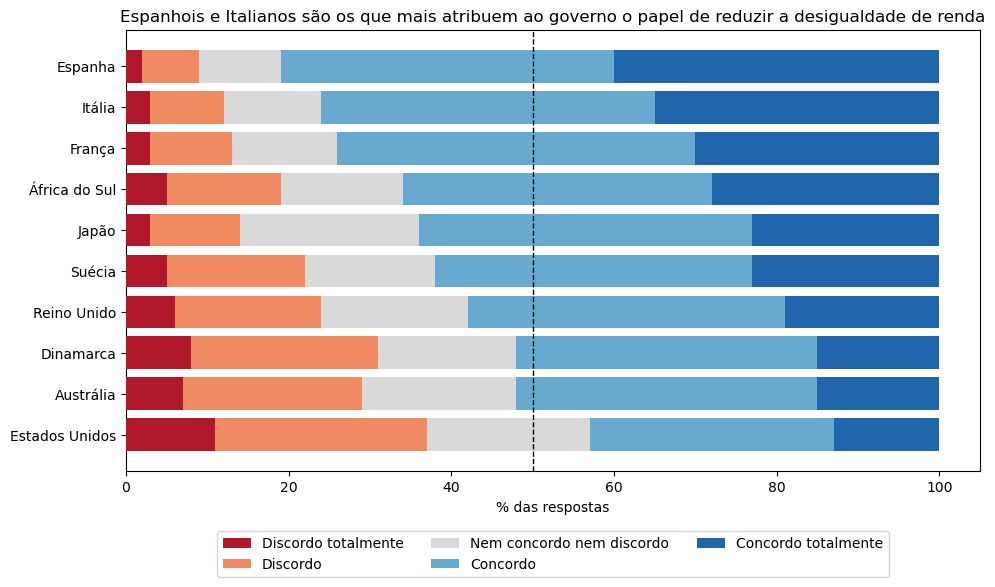

In [8]:
# --------------------------------------------------------------------------- #
# Gráfico 3 — Manter a neutra inteira, como um gráfico de barras empilhadas comum
# --------------------------------------------------------------------------- #
categorias = ['Discordo totalmente', 'Discordo', 'Nem concordo nem discordo',
              'Concordo', 'Concordo totalmente']
cores = ['#b2182b', '#ef8a62', '#d9d9d9', '#67a9cf', '#2166ac']

fig, ax = plt.subplots(figsize=(10, 6))

acumulado = np.zeros(len(likert5))
for categoria, cor in zip(categorias, cores):
    ax.barh(posicoes, likert5[categoria], left=acumulado, color=cor, zorder=3, label=categoria)
    acumulado += likert5[categoria].to_numpy()

# Linha tracejada indicando o meio da escala (50%), sobre as barras
ax.axvline(x=50, color='black', linestyle='--', linewidth=1, zorder=4)

ax.set_yticks(posicoes)
ax.set_yticklabels(likert5['pais'])

ax.set_title('Espanhois e Italianos são os que mais atribuem ao governo o papel '
             'de reduzir a desigualdade de renda')
ax.set_xlabel('% das respostas')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

fig.tight_layout()
plt.show()

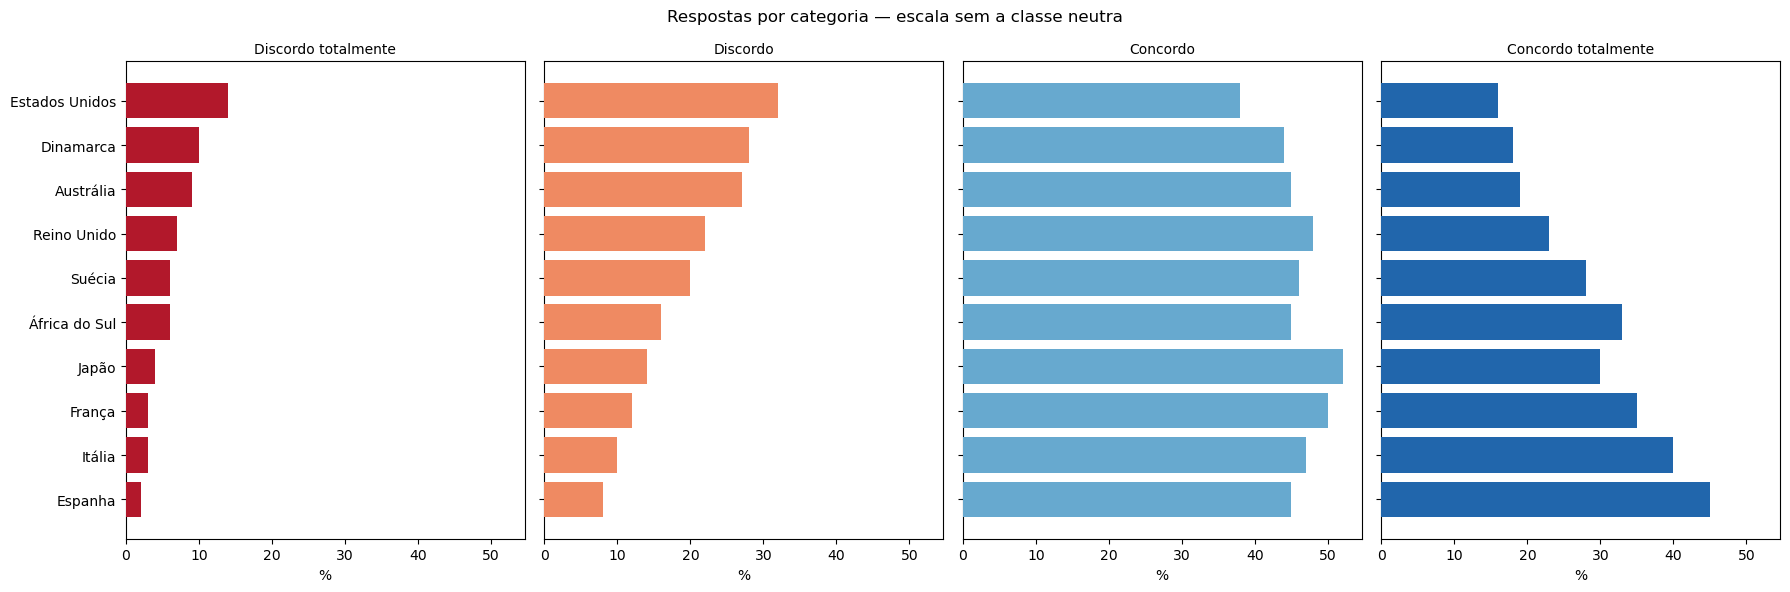

In [9]:
# Múltiplos pequenos — versão sem a categoria neutra (4 faixas)
categorias_4 = ['Discordo totalmente', 'Discordo', 'Concordo', 'Concordo totalmente']
cores_4 = ['#b2182b', '#ef8a62', '#67a9cf', '#2166ac']

fig, eixos = plt.subplots(1, len(categorias_4), figsize=(18, 6), sharey=True, sharex=True)

for ax, categoria, cor in zip(eixos, categorias_4, cores_4):
    ax.barh(posicoes, likert[categoria], color=cor, zorder=3)
    ax.set_title(categoria, fontsize=10)
    ax.set_xlabel('%')

eixos[0].set_yticks(posicoes)
eixos[0].set_yticklabels(likert['pais'])
eixos[0].invert_yaxis()

fig.suptitle('Respostas por categoria — escala sem a classe neutra')
fig.tight_layout()
plt.show()

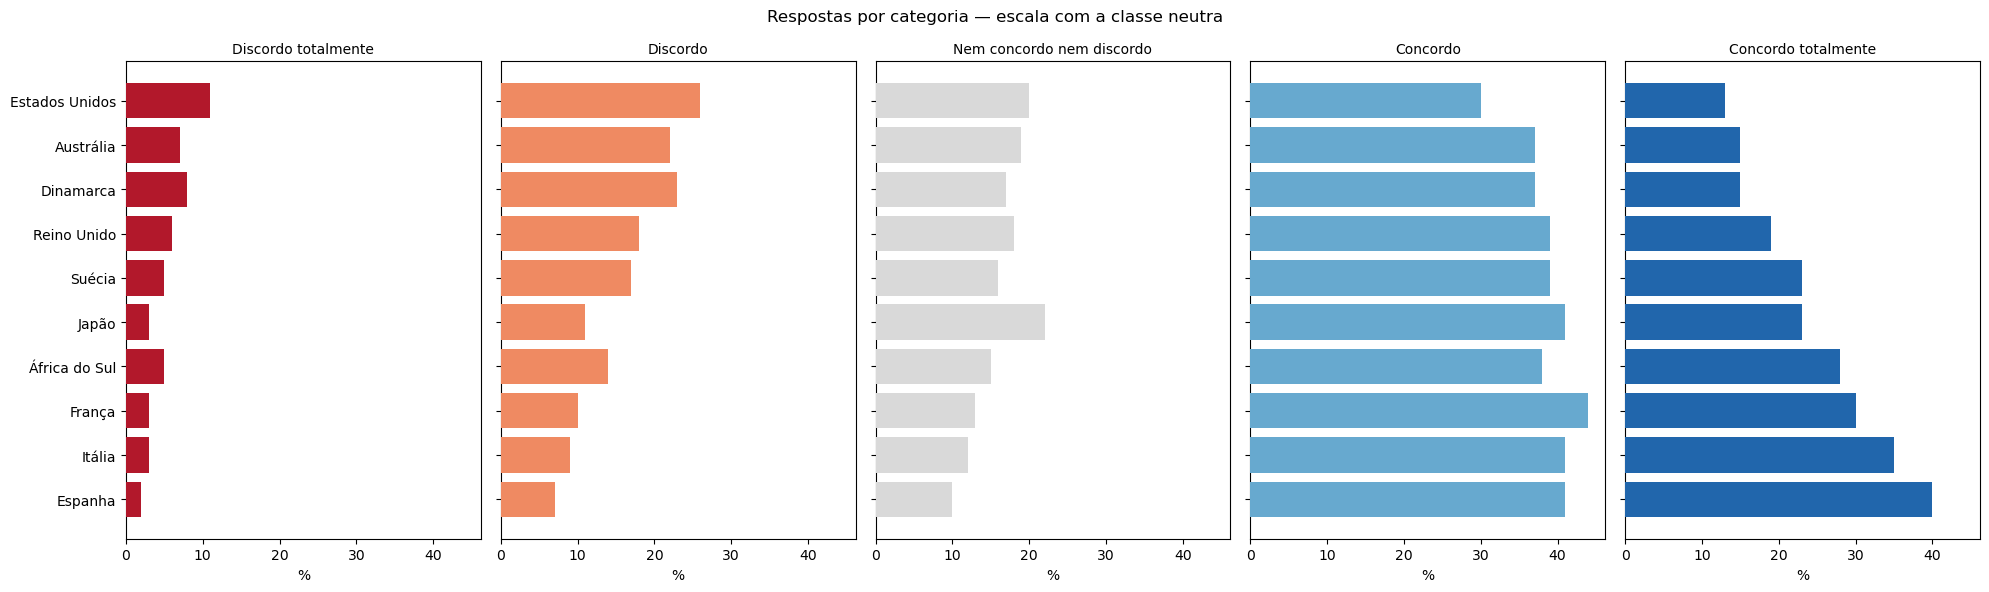

In [10]:
# Múltiplos pequenos — versão com a categoria neutra (5 faixas)
categorias_5 = ['Discordo totalmente', 'Discordo', 'Nem concordo nem discordo',
                'Concordo', 'Concordo totalmente']
cores_5 = ['#b2182b', '#ef8a62', '#d9d9d9', '#67a9cf', '#2166ac']

fig, eixos = plt.subplots(1, len(categorias_5), figsize=(20, 6), sharey=True, sharex=True)

for ax, categoria, cor in zip(eixos, categorias_5, cores_5):
    ax.barh(posicoes, likert5[categoria], color=cor, zorder=3)
    ax.set_title(categoria, fontsize=10)
    ax.set_xlabel('%')

eixos[0].set_yticks(posicoes)
eixos[0].set_yticklabels(likert5['pais'])
eixos[0].invert_yaxis()

fig.suptitle('Respostas por categoria — escala com a classe neutra')
fig.tight_layout()
plt.show()